In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

# --- Carga de datos ---
df = pd.read_csv('creditcard.csv')

print("Shape:", df.shape)
print("\nPrimeras filas:")
df.head()

Shape: (284807, 31)

Primeras filas:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Inspección básica de calidad
print("=== Info General ===")
print(df.info())

print("\n=== Valores Nulos ===")
print(df.isnull().sum().sum(), "valores nulos en total")

print("\n=== Duplicados ===")
print(df.duplicated().sum(), "filas duplicadas")

print("\n=== Estadísticas descriptivas (Amount y Time) ===")
df[['Time', 'Amount', 'Class']].describe()

=== Info General ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


### Why are features V1 to V28 considered "scaled"?

In this dataset, the features `V1` through `V28` are the principal components obtained from a **PCA (Principal Component Analysis)** transformation. 

We can statistically verify that these features have already been standardized by observing two key mathematical properties in our summary statistics:
1. **Mean ≈ 0:** The data distribution is centered around zero.
2. **Standard Deviation (std) ≈ 1:** The variance has been normalized.

*Note:* Unlike V1-V28, the `Amount` and `Time` columns maintain their original magnitudes. We will need to scale them manually during the preprocessing phase to ensure our Machine Learning and Deep Learning models perform optimally and don't introduce magnitude bias.

In [4]:
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Note on Velocity Features (Feature Engineering)
In a real-world banking environment, calculating the time elapsed since the user's last transaction ($\Delta t$) is a highly predictive velocity feature for fraud detection (e.g., detecting rapid card-testing). 

However, because this public dataset lacks an `Account_ID` or `Card_ID` to group by, calculating the difference between consecutive rows would only measure the global transaction frequency of the network, not individual user behavior. Therefore, this feature was considered but omitted due to dataset limitations.

### Imbalance analysis

=== Distribución de Clases ===
Legítimas  (0): 284,315  (99.827%)
Fraudulentas (1): 492  (0.173%)

Ratio de desbalance: 1 fraude por cada 577 transacciones legítimas


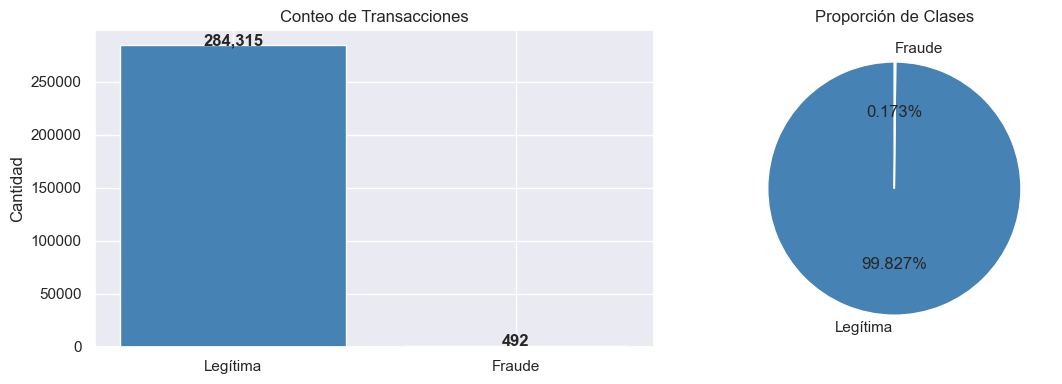

In [5]:
# Distribución de clases
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print("=== Distribución de Clases ===")
print(f"Legítimas  (0): {class_counts[0]:,}  ({class_pct[0]:.3f}%)")
print(f"Fraudulentas (1): {class_counts[1]:,}  ({class_pct[1]:.3f}%)")
print(f"\nRatio de desbalance: 1 fraude por cada {class_counts[0]//class_counts[1]:.0f} transacciones legítimas")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legítima', 'Fraude'], class_counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Conteo de Transacciones')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v+500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(class_pct.values, labels=['Legítima', 'Fraude'],
            autopct='%1.3f%%', colors=['steelblue', 'crimson'], startangle=90)
axes[1].set_title('Proporción de Clases')

plt.tight_layout()

plt.show()

In [6]:
# Amount: ¿Los fraudes tienen montos distintos?
print(df.groupby('Class')['Amount'].describe().round(2))


          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


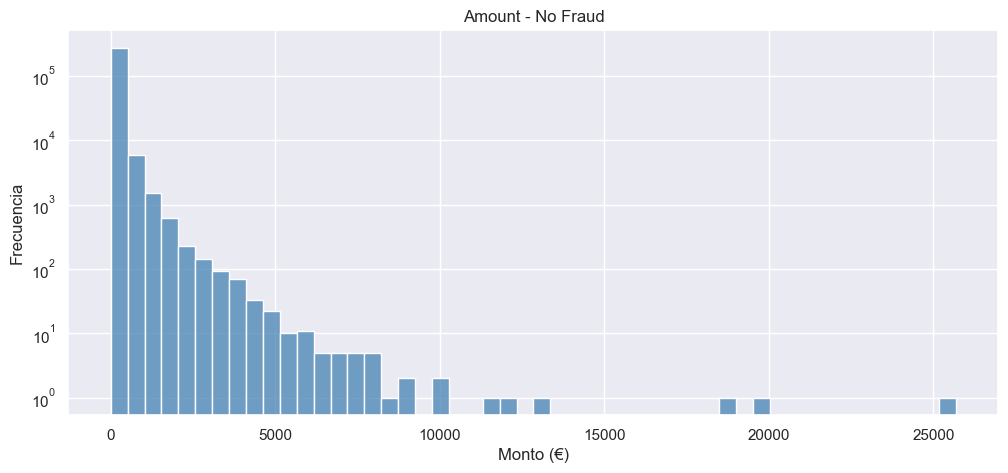

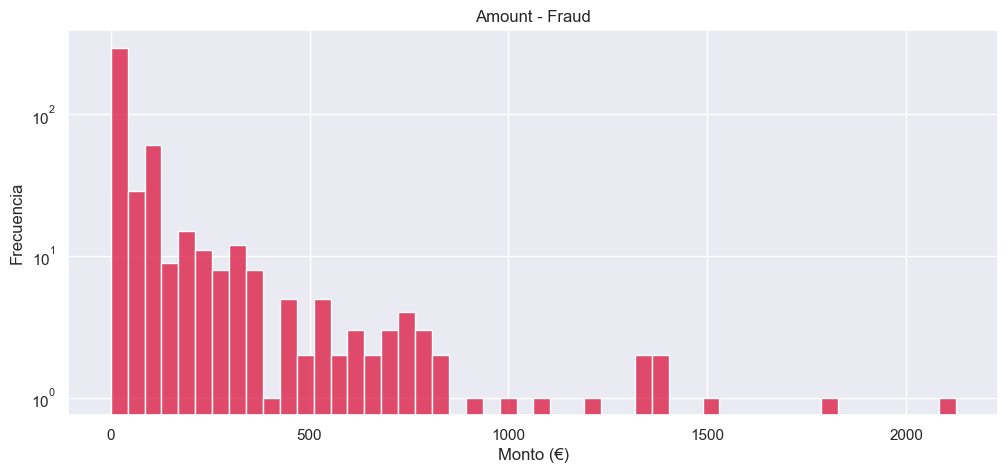

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Gráfica 1: Transacciones Legítimas ---
sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='steelblue')
plt.title("Amount - No Fraud")
plt.xlabel("Monto (€)")
plt.ylabel("Frecuencia")
plt.yscale('log')  
plt.show()

# --- Gráfica 2: Fraudes ---
sns.histplot(df[df['Class']==1]['Amount'], bins=50, color='crimson')
plt.title("Amount - Fraud")
plt.xlabel("Monto (€)")
plt.ylabel("Frecuencia")
plt.yscale('log')  
plt.show()



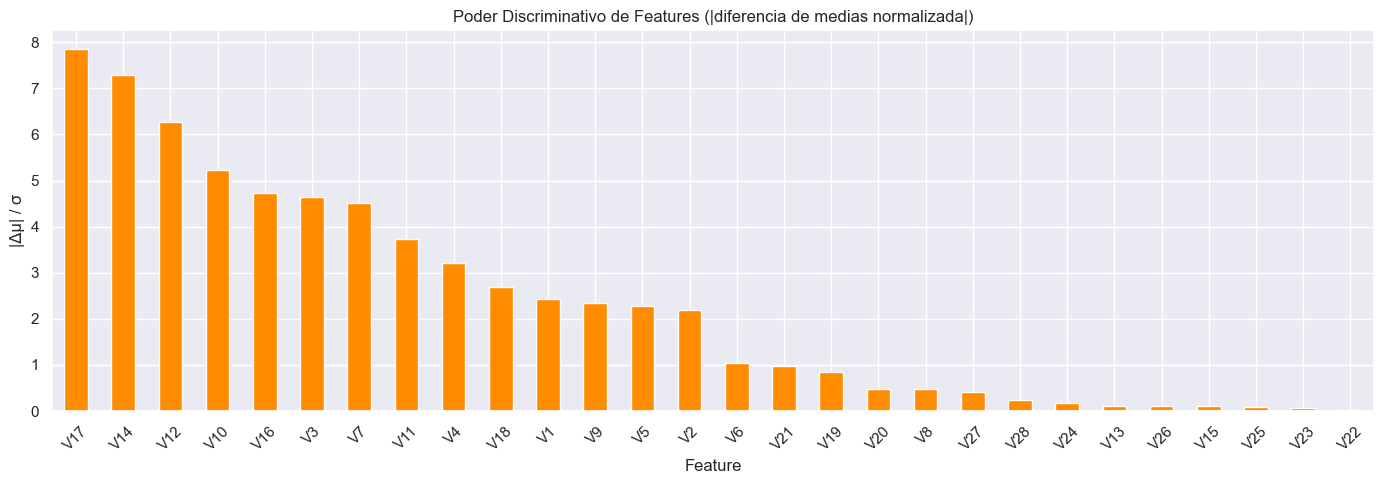


Top 10 features más discriminativas:
V17    7.861863
V14    7.285436
V12    6.275236
V10    5.222673
V16    4.732777
V3     4.646614
V7     4.509253
V11    3.729500
V4     3.213497
V18    2.684633
dtype: float64


In [8]:
# ¿Cuáles features V1-V28 discriminan mejor entre clases?
# Usamos la diferencia de medias normalizadas como proxy rápido
feature_cols = [f'V{i}' for i in range(1, 29)]
#Se defne la media de las variables correspondiente a cada clase
means_fraud = df[df['Class']==1][feature_cols].mean()
means_legit = df[df['Class']==0][feature_cols].mean()
std_all = df[feature_cols].std()
#Se analiza su funcion de poder para definir la utilidad de cada clase para la clasificacion
discrimination = ((means_fraud - means_legit) / std_all).abs().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
discrimination.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Poder Discriminativo de Features (|diferencia de medias normalizada|)')
plt.xlabel('Feature')
plt.ylabel('|Δμ| / σ')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTop 10 features más discriminativas:")
print(discrimination.head(10))

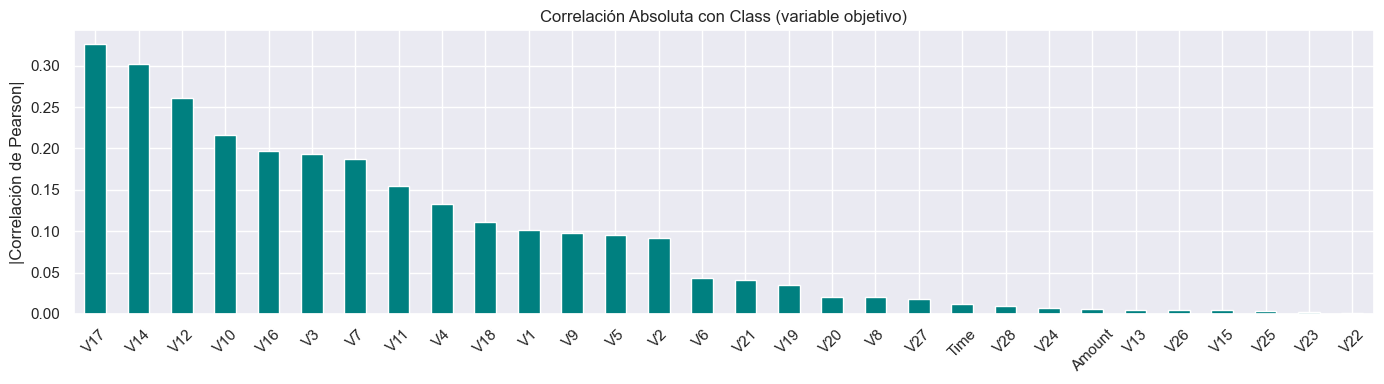

In [13]:
# Correlación de features con la clase objetivo
correlations = df[feature_cols + ['Amount', 'Time']].corrwith(df['Class']).abs().sort_values(ascending=False)

plt.figure(figsize=(14, 4))
correlations.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Correlación Absoluta con Class (variable objetivo)')
plt.ylabel('|Correlación de Pearson|')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

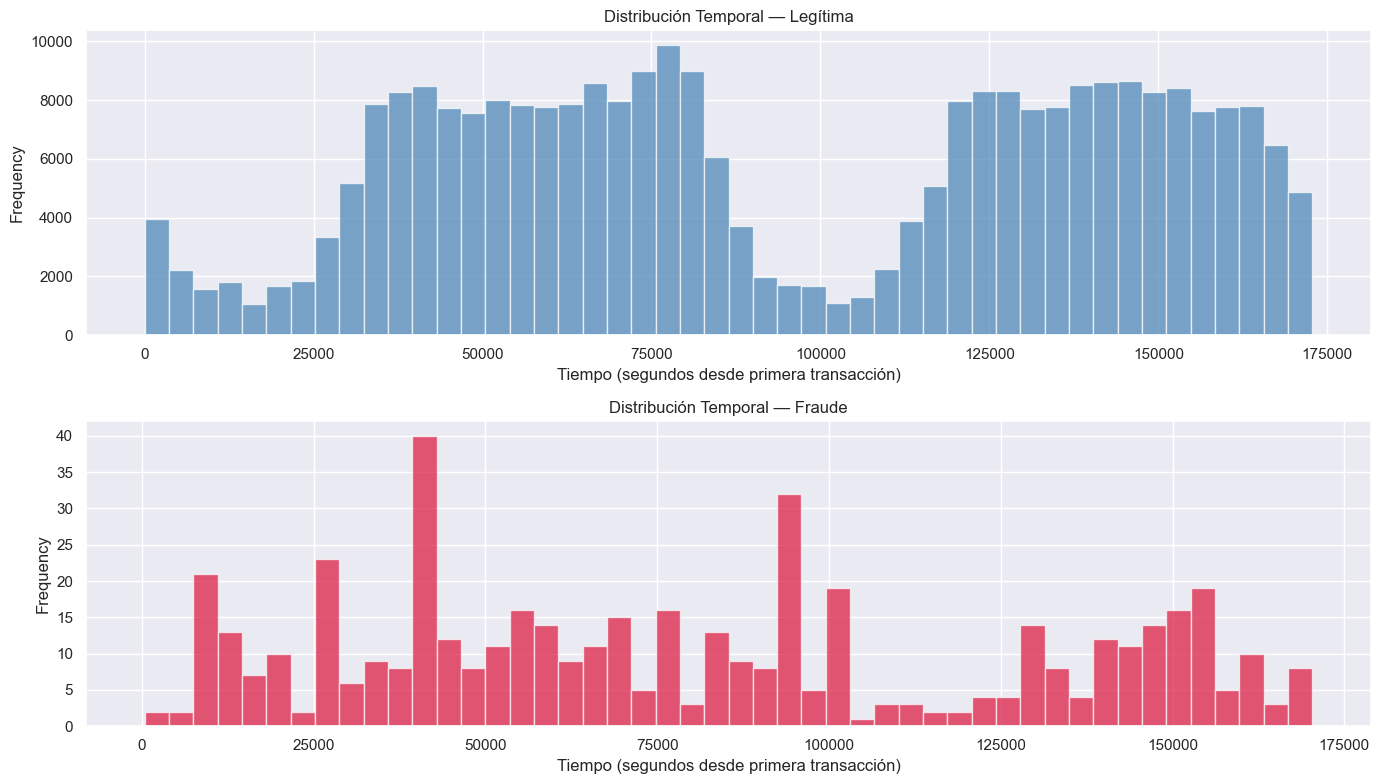

In [14]:
# Distribución temporal: ¿los fraudes ocurren en ciertos momentos?
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for cls, color, label, ax in zip([0,1], ['steelblue','crimson'], ['Legítima','Fraude'], axes):
    df[df['Class']==cls]['Time'].plot(kind='hist', bins=48, ax=ax,
                                      color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'Distribución Temporal — {label}')
    ax.set_xlabel('Tiempo (segundos desde primera transacción)')

plt.tight_layout()
plt.show()